# Network Traffic Behavior Clustering

Discover common flow behaviors and isolate unusual scan-like traffic without using labels during training.

**Safety and scope:** This project uses synthetic, non-sensitive telemetry for defensive analytics. It does not perform exploitation or execute malicious content.

## Goal

Implement K-means from scratch, profile each cluster, and measure cluster purity against hidden synthetic labels.


## Setup

The notebook is deterministic, runs offline, and implements the core analytical method directly with NumPy and Pandas so the modeling logic remains inspectable.


In [1]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 120)

def kmeans(values, clusters, iterations=80):
    centroids = values[rng.choice(len(values), clusters, replace=False)].copy()
    labels = np.zeros(len(values), dtype=int)
    for _ in range(iterations):
        distances = ((values[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        new_labels = distances.argmin(axis=1)
        new_centroids = np.vstack([
            values[new_labels == cluster].mean(axis=0)
            if np.any(new_labels == cluster) else centroids[cluster]
            for cluster in range(clusters)
        ])
        if np.allclose(new_centroids, centroids, atol=1e-5):
            labels = new_labels
            break
        centroids = new_centroids
        labels = new_labels
    return labels, centroids


## Steps

### 1. Generate synthetic network flows


In [2]:
behavior_specs = {
    "web": ([5.0, 7.8, 2.0, 0.08], [0.5, 0.6, 0.4, 0.03], 260),
    "dns": ([3.2, 3.8, 1.2, 0.02], [0.35, 0.45, 0.25, 0.02], 180),
    "file_transfer": ([7.0, 10.2, 4.1, 0.14], [0.55, 0.7, 0.45, 0.05], 130),
    "port_scan": ([1.7, 2.0, 6.2, 0.78], [0.30, 0.35, 0.50, 0.08], 90),
}

flow_parts = []
for behavior, (means, scales, count) in behavior_specs.items():
    values = rng.normal(means, scales, size=(count, 4))
    part = pd.DataFrame(values, columns=["log_packets", "log_bytes", "log_destinations", "syn_ratio"])
    part["behavior"] = behavior
    flow_parts.append(part)

flows = pd.concat(flow_parts, ignore_index=True)
flows["syn_ratio"] = flows["syn_ratio"].clip(0, 1)
print("Flow count:", len(flows))
print(flows.groupby("behavior").size().to_string())
print("\nSample flows:")
print(flows.sample(6, random_state=SEED).round(3).to_string(index=False))


Flow count: 660
behavior
dns              180
file_transfer    130
port_scan         90
web              260

Sample flows:
 log_packets  log_bytes  log_destinations  syn_ratio      behavior
       1.703      2.503             6.478      0.643     port_scan
       7.167     10.136             3.861      0.251 file_transfer
       4.157      7.304             2.099      0.075           web
       6.398     10.919             3.235      0.196 file_transfer
       4.924      8.030             2.400      0.048           web
       6.516     10.672             4.487      0.218 file_transfer


### 2. Cluster and profile behaviors


In [3]:
feature_names = ["log_packets", "log_bytes", "log_destinations", "syn_ratio"]
raw_features = flows[feature_names].to_numpy(float)
scaled_features = (raw_features - raw_features.mean(axis=0)) / raw_features.std(axis=0)
cluster_label, centroids = kmeans(scaled_features, clusters=4)
flows["cluster"] = cluster_label

cluster_profiles = flows.groupby("cluster")[feature_names].mean().round(3)
contingency = pd.crosstab(flows["cluster"], flows["behavior"])
majority_correct = contingency.max(axis=1).sum()
cluster_purity = majority_correct / len(flows)

print("Cluster profiles:")
print(cluster_profiles.to_string())
print("\nCluster-to-hidden-label comparison:")
print(contingency.to_string())
print("\nCluster purity:", round(cluster_purity, 3))


Cluster profiles:
         log_packets  log_bytes  log_destinations  syn_ratio
cluster                                                     
0              6.892     10.240             4.091      0.128
1              1.741      2.015             6.197      0.795
2              3.209      3.756             1.159      0.022
3              4.974      7.775             2.001      0.079

Cluster-to-hidden-label comparison:
behavior  dns  file_transfer  port_scan  web
cluster                                     
0           0            130          0    0
1           0              0         90    0
2         180              0          0    0
3           0              0          0  260

Cluster purity: 1.0


## Visual Insights & ML Extension

The original transparent method remains intact. This extension adds an explicit visual story, a stronger scikit-learn benchmark, and analyst-focused interpretation. All evaluation uses held-out or label-free synthetic examples as appropriate.

**Reading the results:** model scores describe this generated dataset only. They are not production performance claims and should not replace temporal validation, calibration, drift checks, or human review.


 clusters  silhouette  inertia
        2       0.673 1112.994
        3       0.621  419.894
        4       0.718  121.546
        5       0.542  108.215
        6       0.458  100.918
        7       0.376   93.698

Analyst takeaways:
- Silhouette analysis selects 4 clusters (score 0.718).
- Cluster 1 has the highest mean SYN ratio and is the best candidate for scan-behavior review.
- PCA is used only for visualization; the cluster model retains the full standardized feature space.
- Refit against time windows and segment by protocol before using cluster rarity as an alert.
/Users/vinaysheelkapgate/Documents/Codex/2026-08-12/can/work/cybersecurity-analytics/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of co

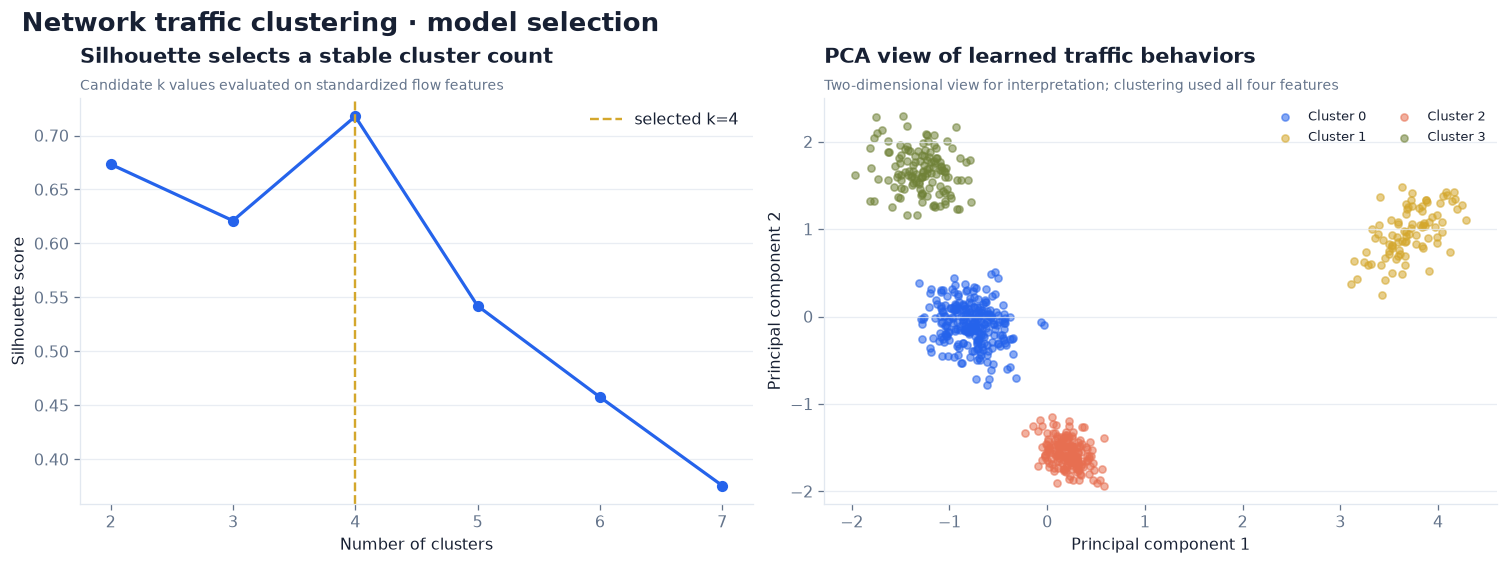

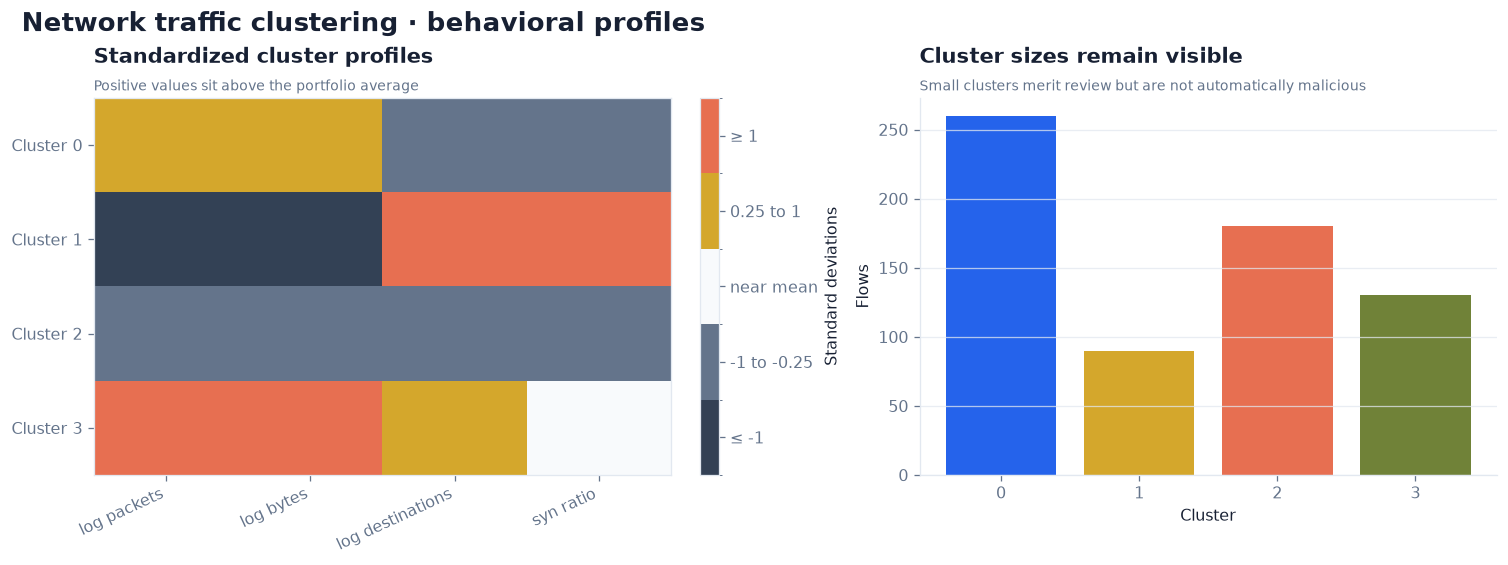

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 42)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def binary_model_comparison(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.28,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows = []
    probabilities = {}
    fitted = {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

cluster_features = flows[["log_packets", "log_bytes", "log_destinations", "syn_ratio"]]
cluster_scaled = StandardScaler().fit_transform(cluster_features)
cluster_trials = []
fitted_trials = {}
for candidate_k in range(2, 8):
    candidate_model = KMeans(n_clusters=candidate_k, n_init=20, random_state=SEED)
    candidate_labels = candidate_model.fit_predict(cluster_scaled)
    cluster_trials.append({
        "clusters": candidate_k,
        "silhouette": silhouette_score(cluster_scaled, candidate_labels),
        "inertia": candidate_model.inertia_,
    })
    fitted_trials[candidate_k] = (candidate_model, candidate_labels)
cluster_diagnostics = pd.DataFrame(cluster_trials)
selected_k = int(cluster_diagnostics.loc[cluster_diagnostics["silhouette"].idxmax(), "clusters"])
selected_model, selected_labels = fitted_trials[selected_k]
projection = PCA(n_components=2, random_state=SEED).fit_transform(cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].plot(cluster_diagnostics["clusters"], cluster_diagnostics["silhouette"], marker="o", color=PALETTE["blue"], linewidth=2)
axes[0].axvline(selected_k, color=PALETTE["gold"], linestyle="--", label=f"selected k={selected_k}")
axes[0].legend(frameon=False)
polish_axis(axes[0], "Silhouette selects a stable cluster count", "Candidate k values evaluated on standardized flow features", "Number of clusters", "Silhouette score")

cluster_colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["orange"], PALETTE["olive"], PALETTE["pink"], PALETTE["muted"]]
for cluster_id in range(selected_k):
    member = selected_labels == cluster_id
    axes[1].scatter(projection[member, 0], projection[member, 1], s=20, alpha=0.55, color=cluster_colors[cluster_id % len(cluster_colors)], label=f"Cluster {cluster_id}")
axes[1].legend(frameon=False, ncol=2, fontsize=8)
polish_axis(axes[1], "PCA view of learned traffic behaviors", "Two-dimensional view for interpretation; clustering used all four features", "Principal component 1", "Principal component 2")
fig.suptitle("Network traffic clustering · model selection", fontsize=16, fontweight="bold", x=0.01, ha="left")

selected_profiles = flows.assign(ml_cluster=selected_labels).groupby("ml_cluster")[["log_packets", "log_bytes", "log_destinations", "syn_ratio"]].mean()
profile_z = (selected_profiles - cluster_features.mean()) / cluster_features.std()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
from matplotlib.colors import BoundaryNorm, ListedColormap
profile_colors = ListedColormap(["#334155", "#64748B", "#F8FAFC", "#D4A72C", "#E76F51"])
profile_norm = BoundaryNorm([-2.5, -1.0, -0.25, 0.25, 1.0, 2.5], profile_colors.N, clip=True)
heatmap = axes[0].imshow(profile_z, cmap=profile_colors, norm=profile_norm, aspect="auto")
axes[0].set_xticks(range(len(profile_z.columns)), profile_z.columns.str.replace("_", " "), rotation=25, ha="right")
axes[0].set_yticks(range(len(profile_z)), [f"Cluster {value}" for value in profile_z.index])
axes[0].set_title("Standardized cluster profiles", loc="left", pad=22)
axes[0].text(0, 1.02, "Positive values sit above the portfolio average", transform=axes[0].transAxes, color=PALETTE["muted"], fontsize=9)
colorbar = fig.colorbar(heatmap, ax=axes[0], ticks=[-1.75, -0.625, 0, 0.625, 1.75])
colorbar.ax.set_yticklabels(["≤ -1", "-1 to -0.25", "near mean", "0.25 to 1", "≥ 1"])
colorbar.set_label("Standard deviations")

cluster_sizes = pd.Series(selected_labels).value_counts().sort_index()
axes[1].bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=cluster_colors[:len(cluster_sizes)])
polish_axis(axes[1], "Cluster sizes remain visible", "Small clusters merit review but are not automatically malicious", "Cluster", "Flows")
fig.suptitle("Network traffic clustering · behavioral profiles", fontsize=16, fontweight="bold", x=0.01, ha="left")

scan_like_cluster = int(selected_profiles["syn_ratio"].idxmax())
print(cluster_diagnostics.round(3).to_string(index=False))
print("\nAnalyst takeaways:")
print(f"- Silhouette analysis selects {selected_k} clusters (score {cluster_diagnostics['silhouette'].max():.3f}).")
print(f"- Cluster {scan_like_cluster} has the highest mean SYN ratio and is the best candidate for scan-behavior review.")
print("- PCA is used only for visualization; the cluster model retains the full standardized feature space.")
print("- Refit against time windows and segment by protocol before using cluster rarity as an alert.")


## Checks


In [5]:
assert len(np.unique(cluster_label)) == 4
assert cluster_purity >= 0.85
assert not cluster_profiles.isna().any().any()
scan_cluster = contingency["port_scan"].idxmax()
assert cluster_profiles.loc[scan_cluster, "syn_ratio"] > 0.5
print("Checks passed: four stable clusters, strong purity, and a distinct scan-like cluster.")


Checks passed: four stable clusters, strong purity, and a distinct scan-like cluster.


## Next Steps

        - Derive flow features from Zeek, NetFlow, or firewall telemetry.
- Track cluster drift by week to detect emerging behaviors.
- Compare K-means with density-based clustering for irregular traffic shapes.
